# aule — Geographic basemaps with cartopy

This notebook shows how to use the optional `lat`/`lon` arguments on aule's spatial plots to draw real geographic maps with coastlines and borders (requires `aule[geo]`, which installs cartopy).

We use **synthetic but geographically realistic data** — a regular lat/lon grid over a region of interest — so the notebook runs without any real dataset.

In [1]:
!pip install -q aule
!pip install -q "aule[geo]"


## Build a synthetic spatial field on a lat/lon grid

We create a 120×180 grid covering Europe (30°N–70°N, 15°W–55°E) and fill it with a synthetic temperature-like anomaly field that has blobs of positive and negative values, mimicking a real bias map.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ── geographic grid ────────────────────────────────────────────────────────
lat_1d = np.linspace(30, 70, 120)    # 30 °N – 70 °N, 120 rows
lon_1d = np.linspace(-15, 55, 180)   # 15 °W – 55 °E, 180 cols
lon_2d, lat_2d = np.meshgrid(lon_1d, lat_1d)  # (120, 180)

print('lat_2d shape:', lat_2d.shape)
print('lat range:', lat_2d.min(), '–', lat_2d.max())
print('lon range:', lon_2d.min(), '–', lon_2d.max())

lat_2d shape: (120, 180)
lat range: 30.0 – 70.0
lon range: -15.0 – 55.0


In [3]:
# ── synthetic ground truth: a smooth temperature field ─────────────────────
np.random.seed(42)

def _smooth_blobs(lat, lon, n=12, seed=0):
    rng = np.random.default_rng(seed)
    field = np.zeros_like(lat)
    for _ in range(n):
        clat = rng.uniform(lat.min(), lat.max())
        clon = rng.uniform(lon.min(), lon.max())
        amp  = rng.uniform(-1, 1) * rng.choice([-1, 1])
        sigma_lat = rng.uniform(3, 10)
        sigma_lon = rng.uniform(4, 14)
        field += amp * np.exp(
            -((lat - clat)**2 / (2*sigma_lat**2) +
              (lon - clon)**2 / (2*sigma_lon**2))
        )
    field += 0.04 * rng.standard_normal(lat.shape)
    field /= np.max(np.abs(field))
    return field

# ground truth and a 'model prediction' with systematic bias and noise
gt_field   = _smooth_blobs(lat_2d, lon_2d, seed=0)
pred_field = gt_field * 0.85 + 0.08 + 0.08 * np.random.randn(*gt_field.shape)

# aule spatial shape: (H, W, C) — one channel
gt_hwc   = gt_field[:, :, np.newaxis]
pred_hwc = pred_field[:, :, np.newaxis]

print('aule input shape:', gt_hwc.shape)

aule input shape: (120, 180, 1)


## `plot_field_comparison` with geographic basemap

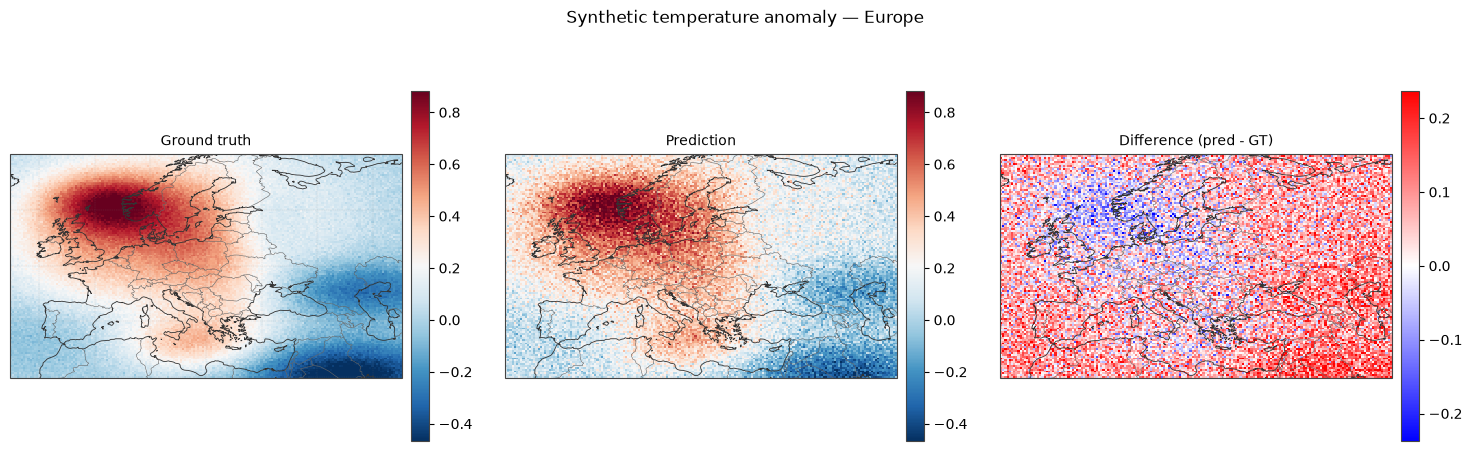

In [4]:
from aule.plots import plot_field_comparison

fig, axes = plot_field_comparison(
    gt_hwc, pred_hwc,
    lat=lat_2d, lon=lon_2d,
    title='Synthetic temperature anomaly — Europe',
)

## `plot_bias_map` on the geographic grid

We pass a small batch (repeating the field 5× with slight noise) so the mean bias is meaningful.

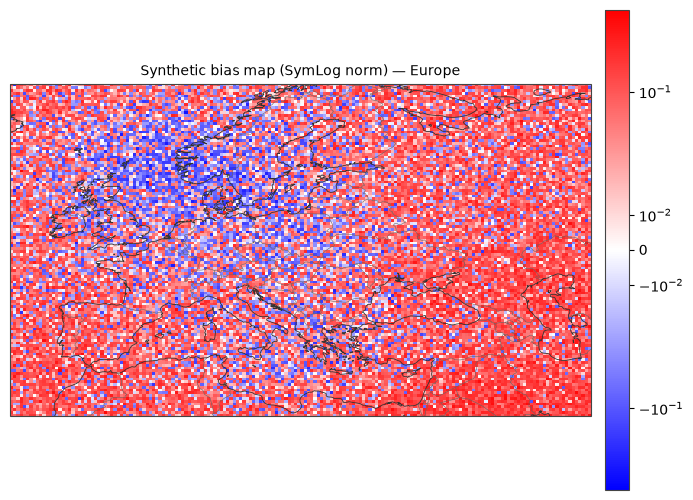

In [5]:
from aule.plots import plot_bias_map

B = 5
gt_batch   = gt_hwc[np.newaxis].repeat(B, axis=0)    # (5, H, W, 1) → bhwc
pred_batch = pred_hwc[np.newaxis].repeat(B, axis=0) + 0.05 * np.random.randn(B, *gt_hwc.shape)

fig, ax = plot_bias_map(
    gt_batch, pred_batch,
    lat=lat_2d, lon=lon_2d,
    norm_type='symlog', norm_kwargs={'linthresh': 0.02},
    title='Synthetic bias map (SymLog norm) — Europe',
)

## `plot_error_map` — absolute and signed error

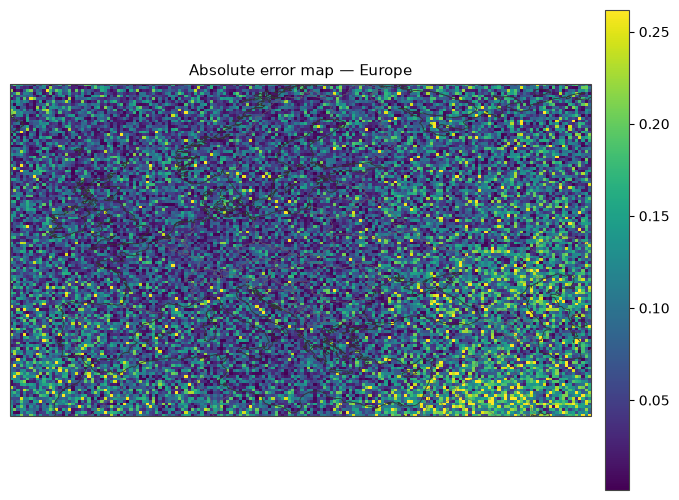

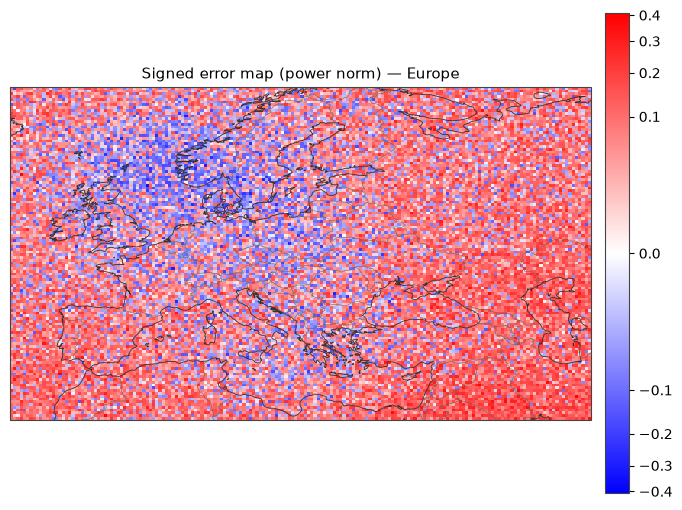

In [6]:
from aule.plots import plot_error_map

fig, ax = plot_error_map(
    gt_hwc, pred_hwc,
    lat=lat_2d, lon=lon_2d,
    abs_error=True,
    title='Absolute error map — Europe',
)

fig, ax = plot_error_map(
    gt_hwc, pred_hwc,
    lat=lat_2d, lon=lon_2d,
    abs_error=False,
    norm_type='power', norm_kwargs={'gamma': 0.4},
    title='Signed error map (power norm) — Europe',
)

## `plot_correlation_map` — pixel-wise temporal correlation

We need a time series: stack 30 slightly-varied realisations of the field as batch members and compute the per-pixel correlation.

r_map shape: (120, 180, 1)
mean r: 0.95


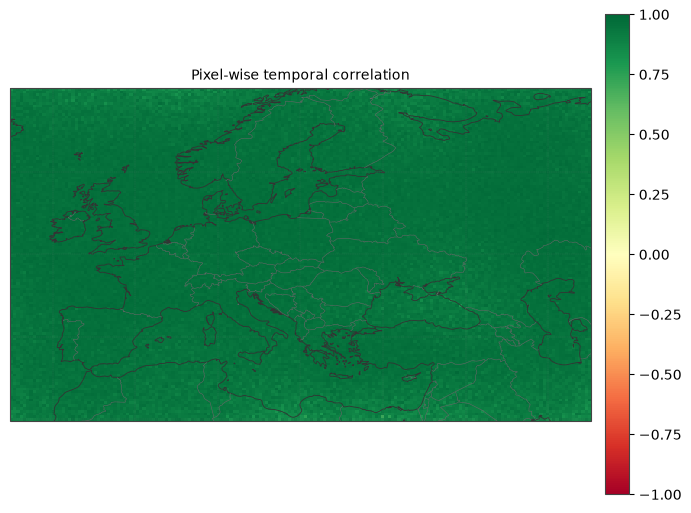

In [7]:
from aule.metrics import pixelwise_temporal_correlation
from aule.plots  import plot_correlation_map

T = 30
# (batch=T, H, W, C)
gt_time   = np.stack([
    _smooth_blobs(lat_2d, lon_2d, seed=t)[:, :, np.newaxis] for t in range(T)
], axis=0)
pred_time = gt_time * 0.9 + 0.1 * np.random.randn(*gt_time.shape)

r_map = pixelwise_temporal_correlation(gt_time, pred_time)  # (H, W, C)
print('r_map shape:', r_map.shape)
print('mean r:', round(float(r_map.mean()), 3))

fig, ax = plot_correlation_map(r_map, lat=lat_2d, lon=lon_2d)

## `plot_ensemble_spread_map` on a geo grid

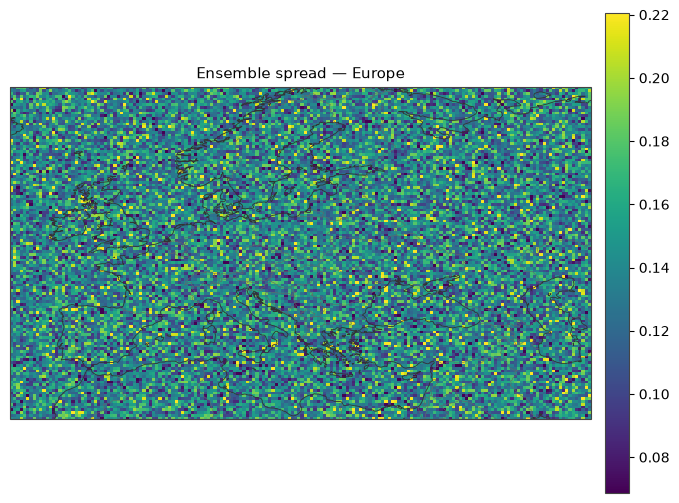

In [8]:
from aule.plots import plot_ensemble_spread_map

M = 10
# ensemble: (M, H, W, C) — bhwc default
ensemble = np.stack([
    gt_hwc + 0.15 * np.random.randn(*gt_hwc.shape) for _ in range(M)
], axis=0)

fig, ax = plot_ensemble_spread_map(
    ensemble,
    lat=lat_2d, lon=lon_2d,
    title='Ensemble spread — Europe',
)

## `plot_hovmoller` — space-time diagram on the geo grid

Hovmoller requires both spatial and temporal extent. We add a time axis simulating 20 weekly snapshots with a northward-propagating signal.

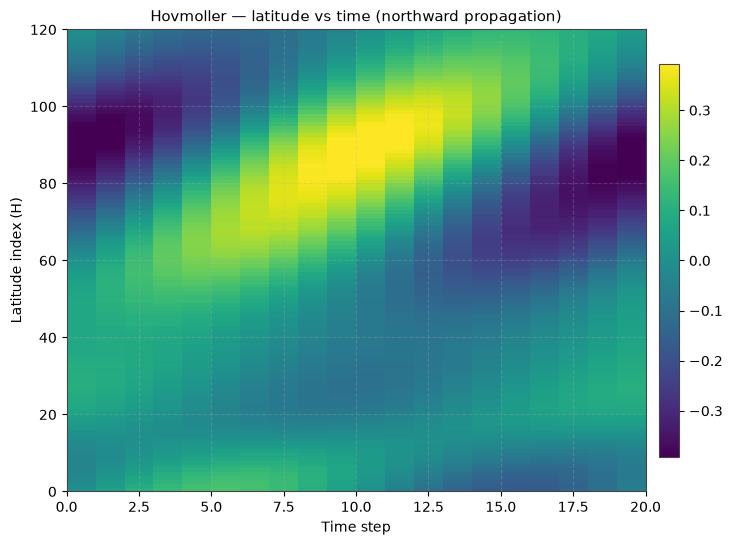

In [9]:
from aule.plots import plot_hovmoller

T_hov = 20
lat_idx = np.arange(lat_2d.shape[0]).reshape(-1, 1, 1, 1)   # (H, 1, 1, 1)
t_idx   = np.arange(T_hov).reshape(1, 1, 1, T_hov)           # (1, 1, 1, T)

# signal that propagates northward over time
propagating = np.sin(
    2*np.pi * (lat_idx / lat_2d.shape[0] - t_idx / T_hov)
) * np.broadcast_to(
    gt_field[:, :, np.newaxis, np.newaxis], (*gt_field.shape, 1, T_hov)
)
# shape: (H, W, C=1, T)

fig, ax = plot_hovmoller(
    propagating,
    axis='lat',
    data_format='hwct',
    title='Hovmoller — latitude vs time (northward propagation)',
)

## Fractions Skill Score on a geo-sized field

FSS doesn't plot directly on a basemap, but it's the go-to verification metric for spatially displaced forecasts on gridded fields — so it fits naturally here.

In [10]:
from aule.metrics import fractions_skill_score

# simulate a spatially-displaced precipitation-like field
precip_gt   = np.maximum(gt_field + 0.3, 0)[:, :, np.newaxis]
precip_pred = np.roll(np.maximum(pred_field + 0.3, 0), shift=5, axis=1)[:, :, np.newaxis]

for w in [3, 9, 21, 51]:
    fss = fractions_skill_score(precip_gt, precip_pred, threshold=0.1, window=w)
    print(f'  FSS (window={w:3d} px): {fss:.3f}')

  FSS (window=  3 px): 0.984
  FSS (window=  9 px): 0.988
  FSS (window= 21 px): 0.993
  FSS (window= 51 px): 0.997
